# INVERTER CIRCUIT 32nm bulk CMOS

> Dataset source repository: https://github.com/GabriellJacinto/Electrical-Behaviour-Prediction
> Dataset Path: Electrical-Behaviour-Prediction/CMOS/32nm/NOT/Models/simu0/Advanced_Algorithms.ipynb

<small>

I'm using simu_0/treated_data dataset in this analysis

**Joined_data.csv:** contém os resultados brutos das simulações elétricas feitas no hspice (Monte Carlo).

**Treated_data.csv:** contém widths, tensões e temperaturas mapeadas.

O notebook advanced_algorithms usa o joined_data e depois gera o treated_data.

*No entanto, ainda não descobri a diferença entre simulação0 e simulação1. Estou usando a simul0.*

</small>

# MLP Training and tuning

In [ ]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, r2_score
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone

In [100]:
import joblib
import pandas as pd

# Loading scalers
scaler_x = joblib.load('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/scaler_x.pkl')
scaler_y = joblib.load('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/scaler_y.pkl')

# Loading split data

X_train_sc = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_train_sc.csv')
X_val_sc   = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_val_sc.csv')
Xte_sc     = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/X_test_sc.csv')

y_train_sc = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_train_sc.csv')
y_val_sc   = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_val_sc.csv')
yte_sc     = pd.read_csv('/home/eduarda/Repos/jupyter_ic/data/processed/CMOS/32nm/NOT/03_train_val_test_splitting/y_test_sc.csv')

print(f"Training set loaded: {X_train_sc.shape}")
print(f"Validation set loaded: {X_val_sc.shape}")
print(f"Test set loaded: {Xte_sc.shape}")

Training set loaded: (64204, 7)
Validation set loaded: (31624, 7)
Test set loaded: (31943, 7)


In [101]:
plots_dir = "/home/eduarda/Repos/jupyter_ic/figures/CMOS/32nm/NOT/05_mlp_training_tuning"

**Loading MLP Models**

In [102]:
# Path
scikitL_model = '/home/eduarda/Repos/jupyter_ic/models/mlp_regressor_SKL_untrained.joblib'

In [103]:
# Loading Scikit-Learn models
scikitL_model_SingleOut_32nm_cmos = joblib.load(scikitL_model)
scikitL_model_MultiOut_32nm_cmos = joblib.load(scikitL_model)
scikitL_SingleOut_7nm_finfet = joblib.load(scikitL_model)
scikitL_model__MultiOut_7nm_finfet = joblib.load(scikitL_model)

In [104]:
# Paths
keras_SingleOut_32nm_cmos = '/home/eduarda/Repos/jupyter_ic/models/mlp_regressor_Keras_SingleOut_untrained_32nm_cmos_inputs_7.keras'
keras_MultiOut_32nm_cmos = '/home/eduarda/Repos/jupyter_ic/models/mlp_regressor_Keras_MultiOut_untrained_32nm_cmos_inputs_7.keras'
keras_SingleOut_7nm_finfet = '/home/eduarda/Repos/jupyter_ic/models/mlp_regressor_Keras_SingleOut_untrained_7nm_finfet_inputs_5.keras'
keras_MultiOut_7nm_finfet = '/home/eduarda/Repos/jupyter_ic/models/mlp_regressor_Keras_MultiOut_untrained_7nm_finfet_inputs_5.keras'

In [105]:
# Loading Keras models
keras_model_SingleOut_32nm_cmos = tf.keras.models.load_model(keras_SingleOut_32nm_cmos)
keras_model_MultiOut_32nm_cmos = tf.keras.models.load_model(keras_MultiOut_32nm_cmos)
keras_model_SingleOut_7nm_finfet = tf.keras.models.load_model(keras_SingleOut_7nm_finfet)
keras_model_MultiOut_7nm_finfet = tf.keras.models.load_model(keras_MultiOut_7nm_finfet)


/home/eduarda/Repos/jupyter_ic/venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Score functions

In [106]:
scores = {}

In [107]:
def score(model, X, y, target_name, target_variable, target_set):
    pred = model.predict(X)
    r2 = r2_score(y, pred)
    rmse = root_mean_squared_error(y, pred)
    mse = mean_squared_error(y, pred)

    scores[target_name, target_variable, target_set] = {
        'r2': r2,
        'rmse': rmse,
        'mse': mse,
    }
    return scores[target_name, target_variable, target_set]

## CMOS

### Single-output models

**SCIKIT-LEARN**

In [108]:
#### Predicting TPHL

In [109]:
# Training
scikitL_model_SingleOut_32nm_cmos.fit(X_train_sc, y_train_sc['tphl'])

Iteration 1, loss = 0.13839182
Validation score: 0.925934
Iteration 2, loss = 0.02148583
Validation score: 0.973076
Iteration 3, loss = 0.00898416
Validation score: 0.988601
Iteration 4, loss = 0.00369022
Validation score: 0.994741
Iteration 5, loss = 0.00209567
Validation score: 0.996627
Iteration 6, loss = 0.00147060
Validation score: 0.997264
Iteration 7, loss = 0.00112573
Validation score: 0.998109
Iteration 8, loss = 0.00088707
Validation score: 0.998481
Iteration 9, loss = 0.00072745
Validation score: 0.998747
Iteration 10, loss = 0.00060615
Validation score: 0.998929
Iteration 11, loss = 0.00051324
Validation score: 0.999098
Iteration 12, loss = 0.00044589
Validation score: 0.999250
Iteration 13, loss = 0.00039501
Validation score: 0.999224
Iteration 14, loss = 0.00036109
Validation score: 0.999381
Iteration 15, loss = 0.00032303
Validation score: 0.999411
Iteration 16, loss = 0.00029015
Validation score: 0.999487
Iteration 17, loss = 0.00027094
Validation score: 0.999504
Iterat

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [110]:
print(f"Output activation function: {scikitL_model_SingleOut_32nm_cmos.out_activation_}")
print(f"The current loss computed with the loss function: {scikitL_model_SingleOut_32nm_cmos.loss_}")
print(f"The minimum loss reached by the solver throughout fitting: {scikitL_model_SingleOut_32nm_cmos.best_loss_}")
print(f"The number of iterations the solver has run: {scikitL_model_SingleOut_32nm_cmos.n_iter_}")
print(f"Best R2 score that triggered early_stopping: {scikitL_model_SingleOut_32nm_cmos.best_validation_score_}")
print(f"R2 score: {scikitL_model_SingleOut_32nm_cmos.validation_scores_}")
print(f"Number of layers: {scikitL_model_SingleOut_32nm_cmos.n_outputs_}")
print(f"Number of layers: {scikitL_model_SingleOut_32nm_cmos.n_layers_}")
print(f"Number of features seen during fit: {scikitL_model_SingleOut_32nm_cmos.n_features_in_}")

Output activation function: identity
The current loss computed with the loss function: 0.00018926437785591525
The minimum loss reached by the solver throughout fitting: None
The number of iterations the solver has run: 25
Best R2 score that triggered early_stopping: 0.9996589789308129
R2 score: [0.9259337986833247, 0.9730764473279728, 0.9886012261352822, 0.9947414592907207, 0.9966273162359287, 0.9972640462468437, 0.9981089765783292, 0.9984812597778062, 0.9987474258182601, 0.9989294806763483, 0.9990975726046089, 0.9992500599374562, 0.999224025063665, 0.9993811483860466, 0.9994106697800305, 0.9994868546598462, 0.9995044790219242, 0.9994981720657383, 0.9995464704726296, 0.9995535467627854, 0.9995425718136098, 0.9996321095540768, 0.9996405122948304, 0.9996589789308129, 0.9996196237569799]
Number of layers: 1
Number of layers: 3
Number of features seen during fit: 7


In [111]:
# Validation
y_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(X_val_sc)

In [112]:
# Validation R² score
scikitL_model_SingleOut_32nm_cmos.score(X_val_sc, y_val_sc['tphl'])

0.9996754255715159

In [113]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tphl'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(y_val_sc['tphl'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.018045827624443324
clf: MLP, MSE 0.00032565189465112184


In [114]:
score(scikitL_model_SingleOut_32nm_cmos, X_val_sc, y_val_sc['tphl'], 'mlp_S_SKL', 'tphl', 'val')

{'r2': 0.9996754255715159,
 'rmse': 0.018045827624443324,
 'mse': 0.00032565189465112184}

In [116]:
# Testing
y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(Xte_sc)

In [117]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tphl'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(yte_sc['tphl'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

clf: MLP, RMSE: 0.01864515971001044
clf: MLP, MSE 0.00034764198061179667


In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_TPHL.png")
plt.show()
plt.close()

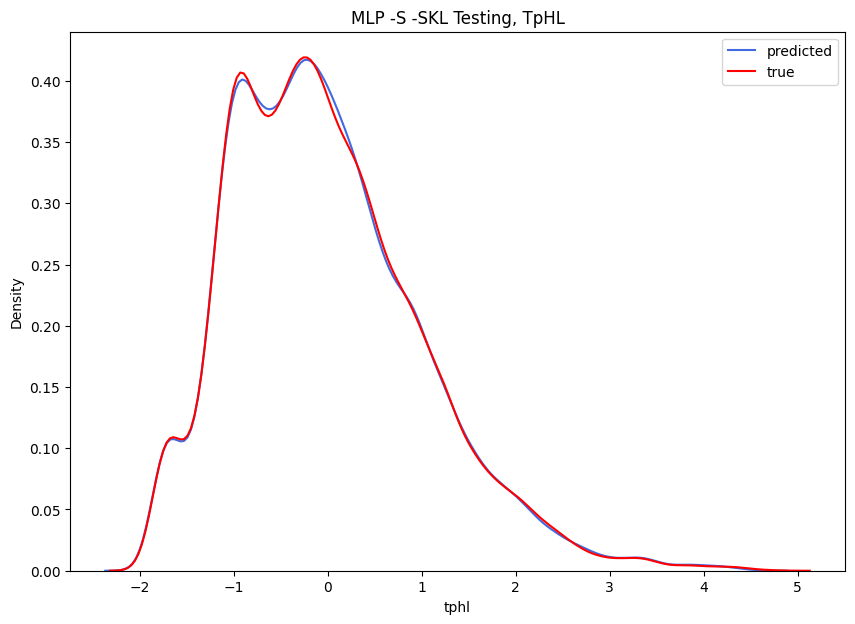

In [118]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tphl'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpHL')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_TPHL.png")
plt.show()
plt.close()

In [ ]:
# SAVE TRAINED
# LOAD CLEAN MODEL

In [ ]:
joblib.dump(scikitL_model_SingleOut_32nm_cmos, "/home/eduarda/Repos/jupyter_ic/models/trained/MLP_Regressor/CMOS/single_output/tphl/mlp_regressor_SKL_TRAINED_32nm_TPHL.joblib")
print("Modelo treinado salvo com sucesso!")

#### Predicting TPLH

In [ ]:
scikitL_model_SingleOut_32nm_cmos = clone(scikitL_model_SingleOut_32nm_cmos)

In [ ]:
# Training
scikitL_model_SingleOut_32nm_cmos.fit(X_train_sc, y_train_sc['tplh'])

In [ ]:
print(f"Output activation function: {scikitL_model_SingleOut_32nm_cmos.out_activation_}")
print(f"The current loss computed with the loss function: {scikitL_model_SingleOut_32nm_cmos.loss_}")
print(f"The minimum loss reached by the solver throughout fitting: {scikitL_model_SingleOut_32nm_cmos.best_loss_}")
print(f"The number of iterations the solver has run: {scikitL_model_SingleOut_32nm_cmos.n_iter_}")
print(f"Best R2 score that triggered early_stopping: {scikitL_model_SingleOut_32nm_cmos.best_validation_score_}")
print(f"R2 score: {scikitL_model_SingleOut_32nm_cmos.validation_scores_}")
print(f"Number of layers: {scikitL_model_SingleOut_32nm_cmos.n_outputs_}")
print(f"Number of layers: {scikitL_model_SingleOut_32nm_cmos.n_layers_}")
print(f"Number of features seen during fit: {scikitL_model_SingleOut_32nm_cmos.n_features_in_}")

In [ ]:
# Validation
y_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(X_val_sc)

In [ ]:
# Validation R² score
scikitL_model_SingleOut_32nm_cmos.score(X_val_sc, y_val_sc['tplh'])

In [ ]:
# Validation error
rmse = root_mean_squared_error(y_val_sc['tplh'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(y_val_sc['tplh'], y_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

In [ ]:
score(scikitL_model_SingleOut_32nm_cmos, X_val_sc, y_val_sc['tplh'], 'mlp_S_SKL', 'tplh', 'val')

In [ ]:
# Testing
y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos = scikitL_model_SingleOut_32nm_cmos.predict(Xte_sc)

In [ ]:
# Testing R² score
scikitL_model_SingleOut_32nm_cmos.score(Xte_sc, yte_sc['tplh'])

In [ ]:
# Testing error
rmse = root_mean_squared_error(yte_sc['tplh'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
mse = mean_squared_error(yte_sc['tplh'], y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos)
print(f'clf: MLP, RMSE: {rmse}')
print(f'clf: MLP, MSE {mse}')

In [ ]:
score(scikitL_model_SingleOut_32nm_cmos, Xte_sc, yte_sc['tplh'], 'mlp_S_SKL', 'tplh', 'test')

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=y_val_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Validation, TpLH')
ax.legend()
plt.savefig(f"{plots_dir}/MLP_S_SKL_VAL_TPLH.png")
plt.show()
plt.close()

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (10,7))
sns.kdeplot(data=y_test_pred_sc_scikitL_model_SingleOut_32nm_cmos, label = 'predicted', ax = ax,color = 'royalblue')
sns.kdeplot(data=yte_sc['tplh'], label = 'true', ax = ax, color = 'red')
ax.set_title('MLP -S -SKL Testing, TpLH')
plt.savefig(f"{plots_dir}/MLP_S_SKL_TEST_TPLH.png")
ax.legend()
plt.show()
plt.close()

In [ ]:
joblib.dump(scikitL_model_SingleOut_32nm_cmos, "/home/eduarda/Repos/jupyter_ic/models/trained/MLP_Regressor/CMOS/single_output/tphl/mlp_regressor_SKL_TRAINED_32nm_TPLH.joblib")
print("Modelo treinado salvo com sucesso!")

In [ ]:
#### Predicting Energy

In [ ]:
scikitL_model_SingleOut_32nm_cmos = clone(scikitL_model_SingleOut_32nm_cmos)

In [ ]:
# Training
scikitL_model_SingleOut_32nm_cmos.fit(X_train_sc, y_train_sc['energy'])

Loading Models

mlp_regressor_SKL_untrained:

will be used

single-output
- tphl (load model)
- tplh (load model)
- energy (load model)

multi-output
- all (load model)

mlp_regressor_K_untrained:

model1: for 1 output
model2 for 2 outputs

will be used

single-output
- tphl (load model1)
- tplh (load model1)
- energy (load model1)

multi-output
- all (load model2)

tunning

isso abaixo é no treinamento

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True
)

history = model.fit(
    X_train_sc, y_train_sc, 
    epochs=500, 
    batch_size=32, 
    validation_data=(X_val_sc, y_val_sc), 
    shuffle=True, 
    callbacks=[early_stop, model_checkpoint]
)

## Save trained models

# FINFET

## Save trained models